# 🤖 Model Training - Large Insurance Dataset (50,000 Records)
**Student:** Sanjay Thakor | **Roll No:** 220390107031

In this notebook I am training and comparing 6 machine learning models on the large insurance dataset.
I will find the best model and save it for use in the Streamlit dashboard.

## Cell 1: Import Libraries

In [1]:
import pandas as pd
import numpy as np
import pickle
import warnings
warnings.filterwarnings('ignore')

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder
from sklearn.linear_model import LinearRegression, Ridge, Lasso
from sklearn.tree import DecisionTreeRegressor
from sklearn.ensemble import RandomForestRegressor, GradientBoostingRegressor
from sklearn.metrics import r2_score, mean_absolute_error, mean_squared_error

import matplotlib.pyplot as plt
import seaborn as sns
plt.style.use('seaborn-v0_8')

print('✅ All libraries imported!')

✅ All libraries imported!


## Cell 2: Load Dataset

In [2]:
df = pd.read_csv('large_insurance_50000.csv')

print(f'✅ Dataset loaded: {df.shape[0]:,} rows x {df.shape[1]} columns')
print(f'Columns: {list(df.columns)}')
print()
df.head()

✅ Dataset loaded: 50,000 rows x 7 columns
Columns: ['age', 'sex', 'bmi', 'children', 'smoker', 'region', 'charges']



,age,sex,bmi,children,smoker,region,charges
0,56,male,17.85,5,no,northwest,16099.70
1,46,female,34.56,2,no,northeast,13383.76
2,32,female,32.45,0,no,southeast,10409.40
3,60,female,21.33,2,yes,northeast,34974.00
4,25,female,39.53,0,no,southwest,11365.84


## Cell 3: Label Encoding (Categorical → Numerical)

In [3]:
# Create encoders for each categorical column
encoders = {}

for col in ['sex', 'smoker', 'region']:
    le = LabelEncoder()
    df[col] = le.fit_transform(df[col])
    encoders[col] = le
    print(f'{col}: {dict(zip(le.classes_, le.transform(le.classes_)))}')

print('\n✅ Encoding complete!')
df.head()

sex: {'female': 0, 'male': 1}
smoker: {'no': 0, 'yes': 1}
region: {'northeast': 0, 'northwest': 1, 'southeast': 2, 'southwest': 3}

✅ Encoding complete!


,age,sex,bmi,children,smoker,region,charges
0,56,1,17.85,5,0,1,16099.70
1,46,0,34.56,2,0,0,13383.76
2,32,0,32.45,0,0,2,10409.40
3,60,0,21.33,2,1,0,34974.00
4,25,0,39.53,0,0,3,11365.84


## Cell 4: Feature Engineering

In [4]:
# Create interaction features to capture combined effects
df['age_bmi']    = df['age'] * df['bmi']       # age and weight combined
df['smoker_age'] = df['smoker'] * df['age']    # smoking effect by age
df['smoker_bmi'] = df['smoker'] * df['bmi']    # smoking effect by BMI

print('New features created:')
print('  age_bmi    = age × bmi')
print('  smoker_age = smoker × age')
print('  smoker_bmi = smoker × bmi')
print(f'\nTotal features now: {df.shape[1] - 1} (excluding target)')
print('\n✅ Feature engineering done!')
df.head()

New features created:
  age_bmi    = age × bmi
  smoker_age = smoker × age
  smoker_bmi = smoker × bmi

Total features now: 9 (excluding target)

✅ Feature engineering done!


,age,sex,bmi,children,smoker,region,charges,age_bmi,smoker_age,smoker_bmi
0,56,1,17.85,5,0,1,16099.70,999.60,0,0.00
1,46,0,34.56,2,0,0,13383.76,1589.76,0,0.00
2,32,0,32.45,0,0,2,10409.40,1038.40,0,0.00
3,60,0,21.33,2,1,0,34974.00,1279.80,60,21.33
4,25,0,39.53,0,0,3,11365.84,988.25,0,0.00


## Cell 5: Train-Test Split

In [5]:
# Define features and target
feature_cols = ['age', 'sex', 'bmi', 'children', 'smoker',
                'region', 'age_bmi', 'smoker_age', 'smoker_bmi']

X = df[feature_cols]
y = df['charges']

# Split: 80% train, 20% test
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

print(f'Total samples  : {len(df):,}')
print(f'Training set   : {len(X_train):,} ({len(X_train)/len(df)*100:.0f}%)')
print(f'Testing set    : {len(X_test):,} ({len(X_test)/len(df)*100:.0f}%)')
print(f'Features used  : {feature_cols}')
print('\n✅ Train-test split done!')

Total samples  : 50,000
Training set   : 40,000 (80%)
Testing set    : 10,000 (20%)
Features used  : ['age', 'sex', 'bmi', 'children', 'smoker', 'region', 'age_bmi', 'smoker_age', 'smoker_bmi']

✅ Train-test split done!


## Cell 6: Define All Models

In [7]:
models = {
    'Linear Regression'   : LinearRegression(),
    'Ridge Regression'    : Ridge(alpha=1.0),
    'Lasso Regression'    : Lasso(alpha=1.0),
    'Decision Tree'       : DecisionTreeRegressor(random_state=42),
    'Random Forest'       : RandomForestRegressor(n_estimators=100, random_state=42),
    'Gradient Boosting'   : GradientBoostingRegressor(n_estimators=100, random_state=42)
}

print('Models to be trained:')
for i, name in enumerate(models.keys(), 1):
    print(f'  {i}. {name}')
print('\n✅ Models defined! Starting training...')

Models to be trained:
  1. Linear Regression
  2. Ridge Regression
  3. Lasso Regression
  4. Decision Tree
  5. Random Forest
  6. Gradient Boosting

✅ Models defined! Starting training...


## Cell 7: Train All Models & Show Results

In [8]:
results = {}

print('🚀 Training all models on 50,000 records...')
print('=' * 60)

for name, model in models.items():
    print(f'\n🔄 Training: {name}...')

    # Train
    model.fit(X_train, y_train)

    # Predict
    y_pred = model.predict(X_test)

    # Metrics
    r2   = r2_score(y_test, y_pred)
    mae  = mean_absolute_error(y_test, y_pred)
    rmse = np.sqrt(mean_squared_error(y_test, y_pred))

    results[name] = {'R2': r2, 'MAE': mae, 'RMSE': rmse, 'model': model}

    print(f'   ✅ Accuracy (R²): {r2*100:.2f}%')
    print(f'   📉 MAE          : ${mae:,.2f}')
    print(f'   📉 RMSE         : ${rmse:,.2f}')

print('\n' + '=' * 60)
print('🎉 All 6 models trained successfully!')

🚀 Training all models on 50,000 records...

🔄 Training: Linear Regression...
   ✅ Accuracy (R²): 93.10%
   📉 MAE          : $1,982.70
   📉 RMSE         : $2,471.47

🔄 Training: Ridge Regression...
   ✅ Accuracy (R²): 93.10%
   📉 MAE          : $1,982.83
   📉 RMSE         : $2,471.58

🔄 Training: Lasso Regression...
   ✅ Accuracy (R²): 93.10%
   📉 MAE          : $1,982.95
   📉 RMSE         : $2,471.70

🔄 Training: Decision Tree...
   ✅ Accuracy (R²): 85.34%
   📉 MAE          : $2,880.87
   📉 RMSE         : $3,601.93

🔄 Training: Random Forest...
   ✅ Accuracy (R²): 92.21%
   📉 MAE          : $2,100.22
   📉 RMSE         : $2,625.17

🔄 Training: Gradient Boosting...
   ✅ Accuracy (R²): 93.12%
   📉 MAE          : $1,974.20
   📉 RMSE         : $2,468.10

🎉 All 6 models trained successfully!


## Cell 8: Model Comparison Table

In [9]:
# Build comparison dataframe
comparison = pd.DataFrame({
    'Model'        : list(results.keys()),
    'Accuracy (%)'  : [results[m]['R2']*100 for m in results],
    'MAE ($)'       : [results[m]['MAE'] for m in results],
    'RMSE ($)'      : [results[m]['RMSE'] for m in results]
})

comparison = comparison.sort_values('Accuracy (%)', ascending=False).reset_index(drop=True)
comparison['Accuracy (%)'] = comparison['Accuracy (%)'].round(2)
comparison['MAE ($)']      = comparison['MAE ($)'].round(2)
comparison['RMSE ($)']     = comparison['RMSE ($)'].round(2)

print('📊 MODEL COMPARISON TABLE')
print('=' * 60)
print(comparison.to_string(index=False))
print('=' * 60)

best_name = comparison.iloc[0]['Model']
best_acc  = comparison.iloc[0]['Accuracy (%)']
best_mae  = comparison.iloc[0]['MAE ($)']
print(f'\n🏆 WINNER: {best_name}')
print(f'   Accuracy : {best_acc:.2f}%')
print(f'   MAE      : ${best_mae:,.2f}')

📊 MODEL COMPARISON TABLE
            Model  Accuracy (%)  MAE ($)  RMSE ($)
Gradient Boosting         93.12  1974.20   2468.10
Linear Regression         93.10  1982.70   2471.47
 Ridge Regression         93.10  1982.83   2471.58
 Lasso Regression         93.10  1982.95   2471.70
    Random Forest         92.21  2100.22   2625.17
    Decision Tree         85.34  2880.87   3601.93

🏆 WINNER: Gradient Boosting
   Accuracy : 93.12%
   MAE      : $1,974.20


## Cell 9: Accuracy Comparison Chart

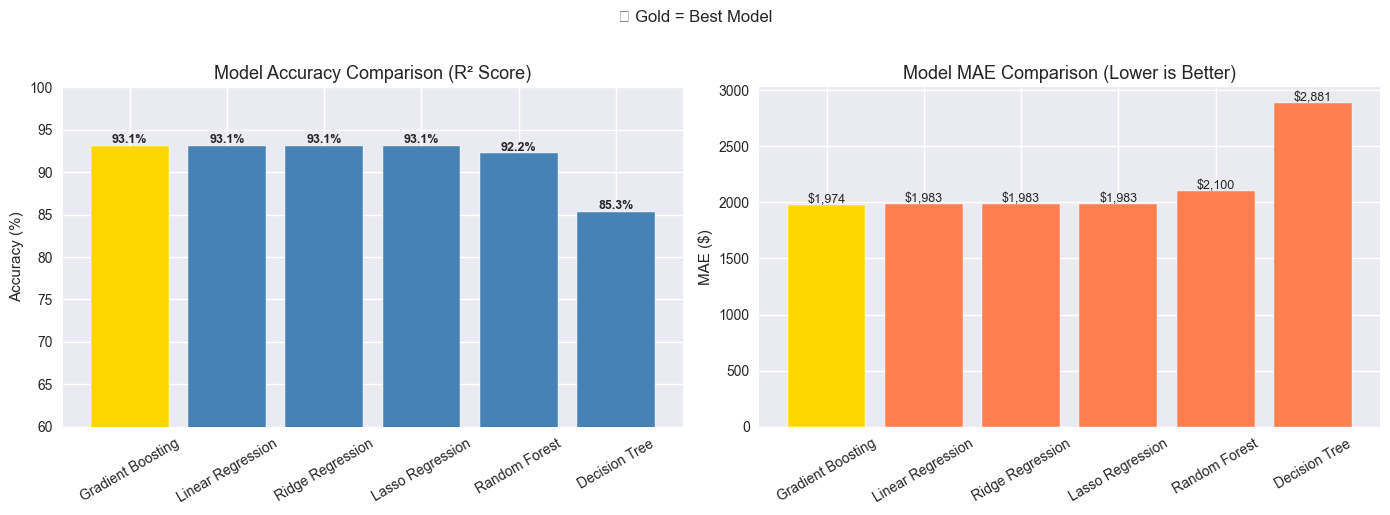

In [10]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Accuracy bar chart
colors = ['gold' if m == best_name else 'steelblue' for m in comparison['Model']]
bars = axes[0].bar(comparison['Model'], comparison['Accuracy (%)'], color=colors, edgecolor='white')
axes[0].set_title('Model Accuracy Comparison (R² Score)', fontsize=13)
axes[0].set_ylabel('Accuracy (%)')
axes[0].set_ylim([60, 100])
axes[0].tick_params(axis='x', rotation=30)
for bar, val in zip(bars, comparison['Accuracy (%)']):
    axes[0].text(bar.get_x() + bar.get_width()/2, val + 0.3,
                 f'{val:.1f}%', ha='center', fontsize=9, fontweight='bold')

# MAE bar chart
colors2 = ['gold' if m == best_name else 'coral' for m in comparison['Model']]
bars2 = axes[1].bar(comparison['Model'], comparison['MAE ($)'], color=colors2, edgecolor='white')
axes[1].set_title('Model MAE Comparison (Lower is Better)', fontsize=13)
axes[1].set_ylabel('MAE ($)')
axes[1].tick_params(axis='x', rotation=30)
for bar, val in zip(bars2, comparison['MAE ($)']):
    axes[1].text(bar.get_x() + bar.get_width()/2, val + 20,
                 f'${val:,.0f}', ha='center', fontsize=9)

plt.suptitle('🏆 Gold = Best Model', fontsize=12, y=1.02)
plt.tight_layout()
plt.show()

## Cell 10: Actual vs Predicted Plot (Best Model)

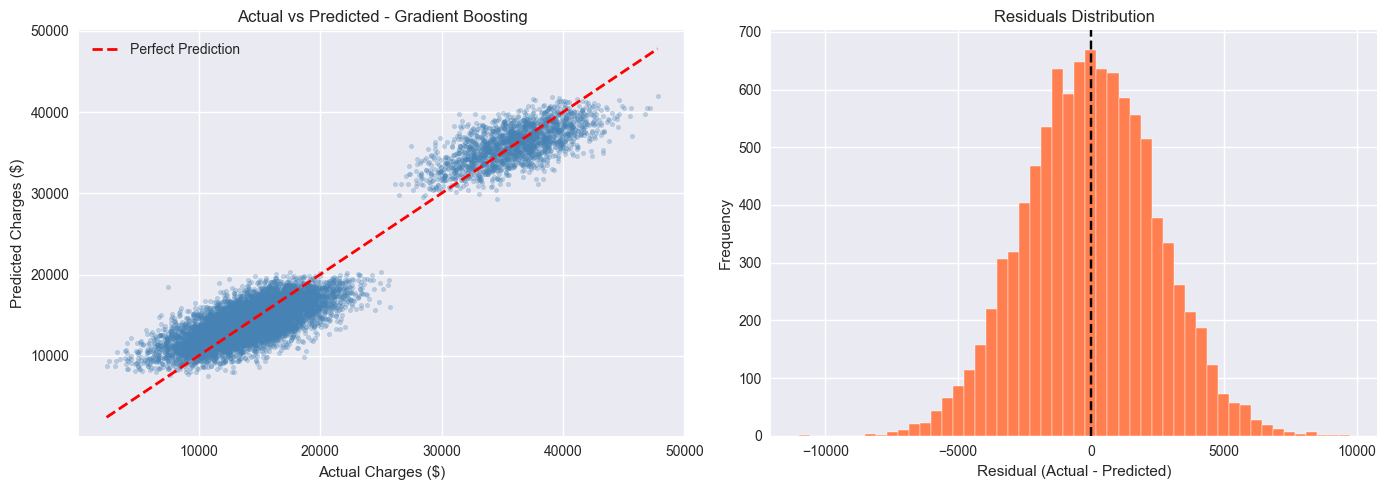

Best Model: Gradient Boosting
R² Score  : 93.12%
MAE       : $1,974.20
RMSE      : $2,468.10


In [11]:
best_model = results[best_name]['model']
y_pred_best = best_model.predict(X_test)

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Actual vs Predicted scatter
axes[0].scatter(y_test, y_pred_best, alpha=0.3, color='steelblue', s=10)
axes[0].plot([y_test.min(), y_test.max()],
             [y_test.min(), y_test.max()], 'r--', lw=2, label='Perfect Prediction')
axes[0].set_title(f'Actual vs Predicted - {best_name}', fontsize=12)
axes[0].set_xlabel('Actual Charges ($)')
axes[0].set_ylabel('Predicted Charges ($)')
axes[0].legend()

# Residuals
residuals = y_test.values - y_pred_best
axes[1].hist(residuals, bins=50, color='coral', edgecolor='white')
axes[1].axvline(0, color='black', linestyle='--')
axes[1].set_title('Residuals Distribution', fontsize=12)
axes[1].set_xlabel('Residual (Actual - Predicted)')
axes[1].set_ylabel('Frequency')

plt.tight_layout()
plt.show()

print(f'Best Model: {best_name}')
print(f'R² Score  : {results[best_name]["R2"]*100:.2f}%')
print(f'MAE       : ${results[best_name]["MAE"]:,.2f}')
print(f'RMSE      : ${results[best_name]["RMSE"]:,.2f}')

## Cell 11: Save Best Model Files

In [12]:
# Save best model
with open('best_model_large.pkl', 'wb') as f:
    pickle.dump(best_model, f)

# Save encoders
with open('encoders_large.pkl', 'wb') as f:
    pickle.dump(encoders, f)

# Save model info
model_info = {
    'model_name' : best_name,
    'r2_score'   : results[best_name]['R2'],
    'mae'        : results[best_name]['MAE'],
    'rmse'       : results[best_name]['RMSE'],
    'dataset'    : 'large_insurance_50000.csv',
    'n_samples'  : len(df),
    'features'   : feature_cols
}
with open('model_info_large.pkl', 'wb') as f:
    pickle.dump(model_info, f)

print('✅ Files saved successfully!')
print('   best_model_large.pkl  → Trained model')
print('   encoders_large.pkl    → Label encoders')
print('   model_info_large.pkl  → Model metadata')
print(f'\n🏆 Best Model : {best_name}')
print(f'   Accuracy   : {results[best_name]["R2"]*100:.2f}%')
print(f'   MAE        : ${results[best_name]["MAE"]:,.2f}')
print(f'   RMSE       : ${results[best_name]["RMSE"]:,.2f}')
print(f'   Dataset    : 50,000 records')

✅ Files saved successfully!
   best_model_large.pkl  → Trained model
   encoders_large.pkl    → Label encoders
   model_info_large.pkl  → Model metadata

🏆 Best Model : Gradient Boosting
   Accuracy   : 93.12%
   MAE        : $1,974.20
   RMSE       : $2,468.10
   Dataset    : 50,000 records
